In [6]:
from google.colab import files

uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset.csv


In [7]:
import pandas as pd

df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
print(df.columns)
df.head()
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df.columns
df['loan_status'].value_counts()

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial

,count
loan_status,
Approved,2656
Rejected,1613


In [8]:
import pandas as pd

df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
df['education'] = df['education'].fillna(df['education'].mode()[0])
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

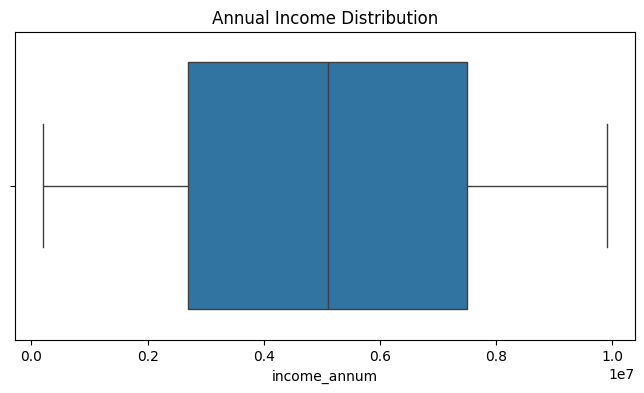

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df['income_annum'])
plt.title('Annual Income Distribution')
plt.show()

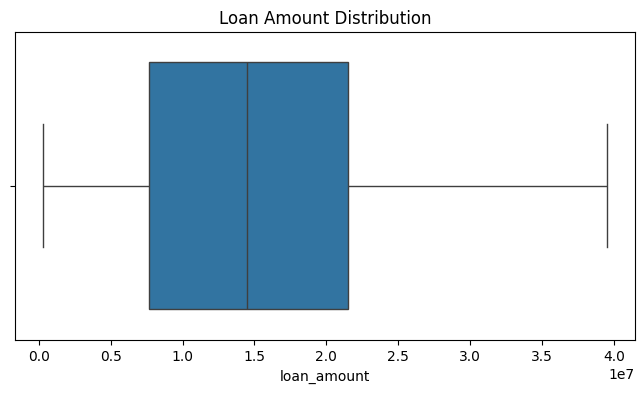

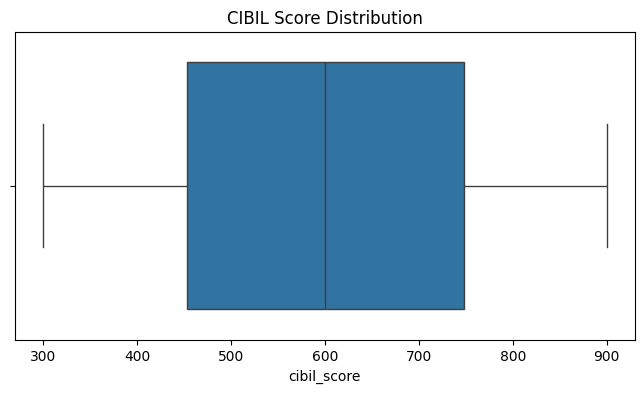

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.boxplot(x=df['loan_amount'])
plt.title('Loan Amount Distribution')
plt.show()
plt.figure(figsize=(8,4))
sns.boxplot(x=df['cibil_score'])
plt.title('CIBIL Score Distribution')
plt.show()

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip().str.lower()
df.head()
df.info()
df.isnull().sum()
df['education'] = df['education'].fillna(df['education'].mode()[0])
encoder = LabelEncoder()

df['education'] = encoder.fit_transform(df['education'])
df['self_employed'] = encoder.fit_transform(df['self_employed'])
df['loan_status'] = encoder.fit_transform(df['loan_status'])
scaler = StandardScaler()

cols = ['income_annum', 'loan_amount', 'cibil_score']

df[cols] = scaler.fit_transform(df[cols])
df.head()
df.info()
df.to_csv('cleaned_loan_data.csv', index=False)
print("Cleaned dataset saved successfully!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
<class 'pandas.core.frame.Data

In [11]:
!ls


cleaned_loan_data.csv  loan_approval_dataset.csv  sample_data


In [12]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_loan_data.csv to cleaned_loan_data (1).csv


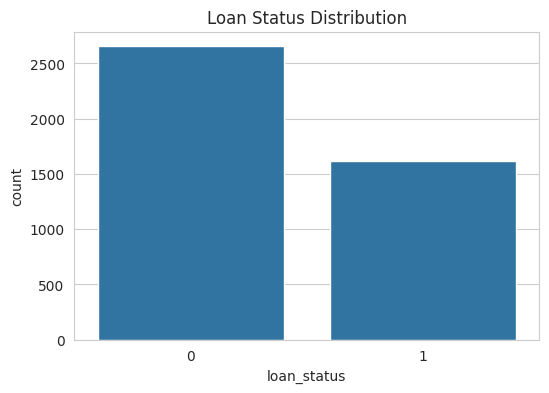

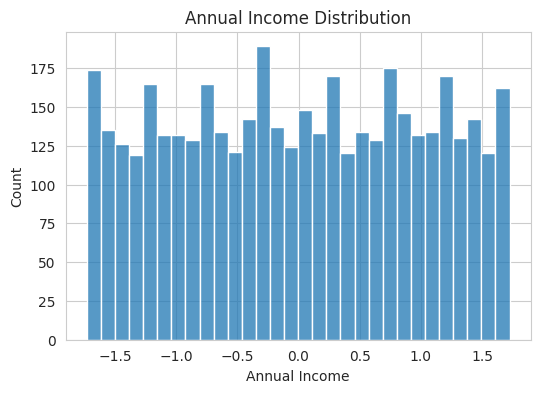

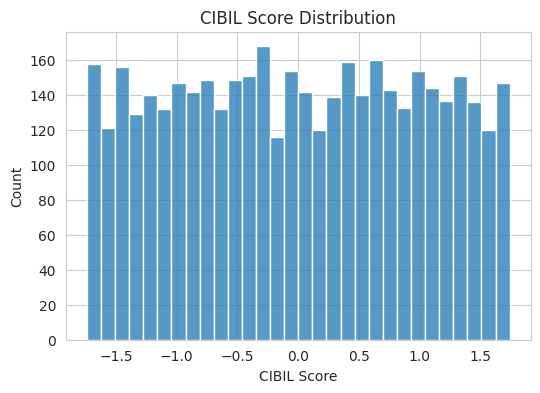

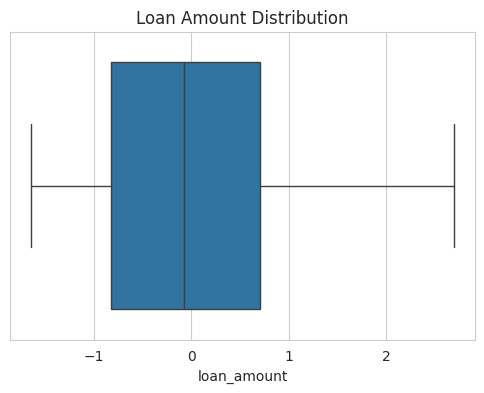

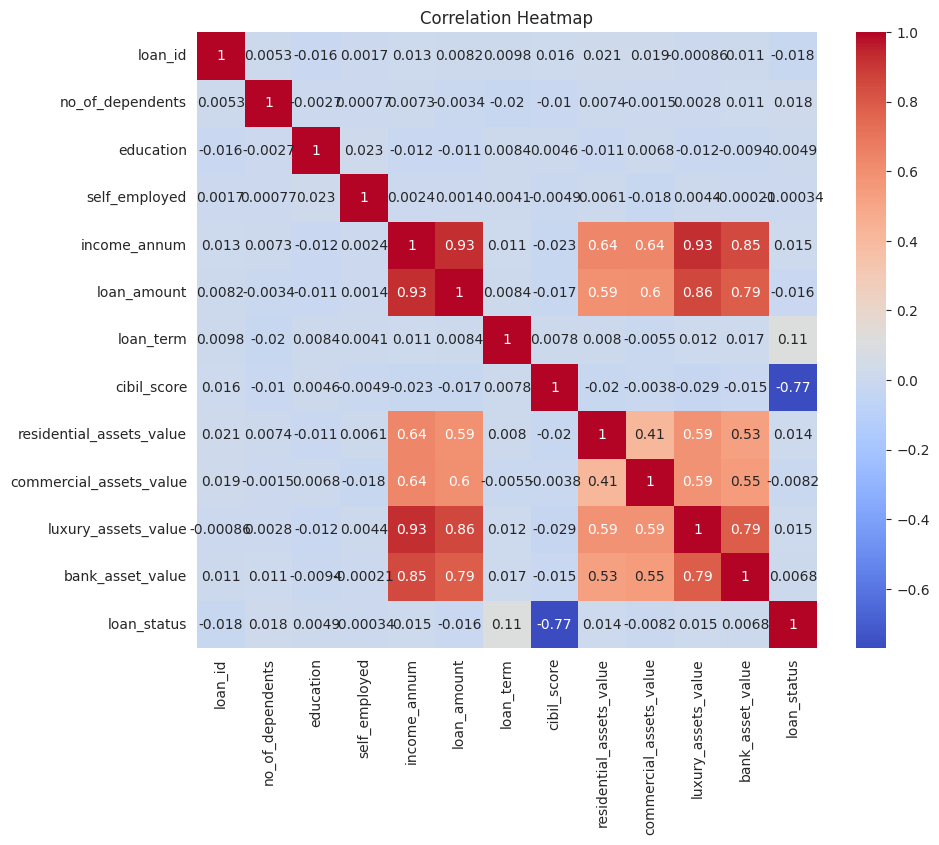

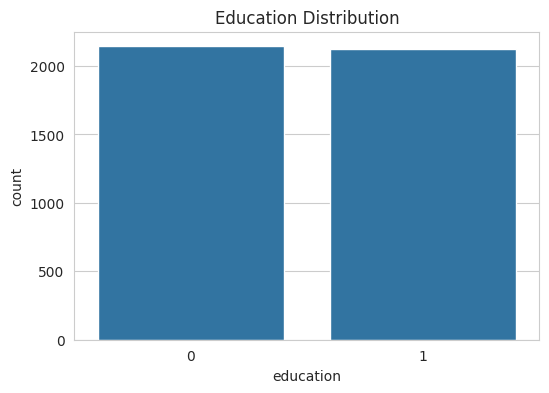

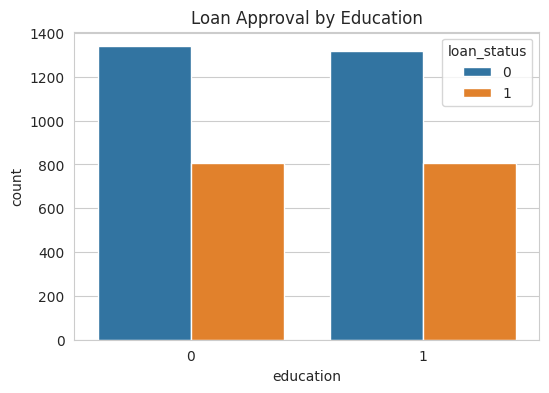

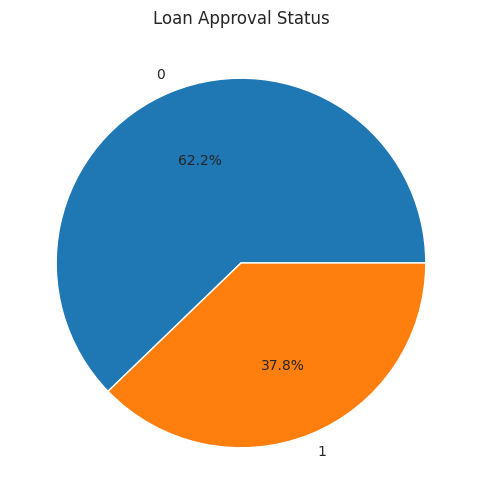

In [13]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("cleaned_loan_data.csv")

# Set graph style
sns.set_style("whitegrid")

# -----------------------------
# Figure 5.1: Loan Status Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

# -----------------------------
# Figure 5.2: Annual Income Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['income_annum'], bins=30)
plt.title('Annual Income Distribution')
plt.xlabel("Annual Income")
plt.show()

# -----------------------------
# Figure 5.3: CIBIL Score Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['cibil_score'], bins=30)
plt.title('CIBIL Score Distribution')
plt.xlabel("CIBIL Score")
plt.show()

# -----------------------------
# Figure 5.4: Loan Amount Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df['loan_amount'])
plt.title('Loan Amount Distribution')
plt.show()

# -----------------------------
# Figure 5.5: Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Figure 5.6: Education Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='education', data=df)
plt.title('Education Distribution')
plt.show()

# -----------------------------
# Figure 5.7: Loan Approval by Education
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title('Loan Approval by Education')
plt.show()

# -----------------------------
# Figure 5.8: Loan Status Pie Chart
# -----------------------------
plt.figure(figsize=(6,6))
df['loan_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Loan Approval Status')
plt.ylabel('')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Accuracy: 0.8969555035128806
[[493  43]
 [ 45 273]]


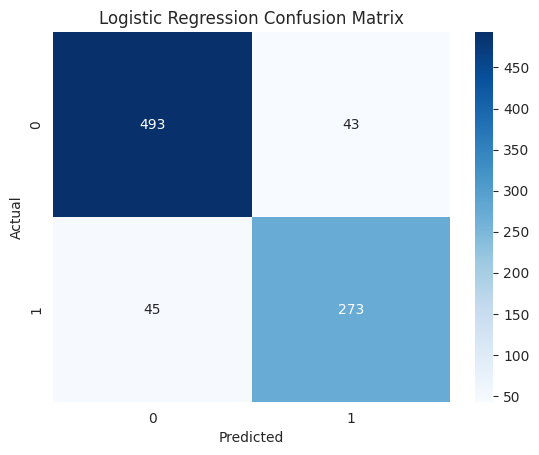

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       536
           1       0.86      0.86      0.86       318

    accuracy                           0.90       854
   macro avg       0.89      0.89      0.89       854
weighted avg       0.90      0.90      0.90       854



In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_lr))

In [16]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.9742388758782201
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.96      0.97      0.97       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [17]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9765807962529274
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



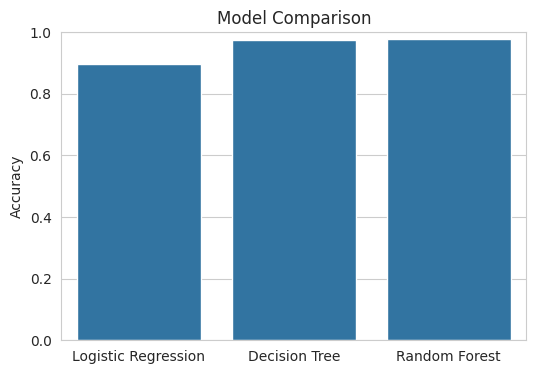

Logistic Regression: 0.8969555035128806
Decision Tree: 0.9742388758782201
Random Forest: 0.9765807962529274


In [ ]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracy = [
    accuracy_lr,
    accuracy_dt,
    accuracy_rf
]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracy)
plt.ylim(0,1)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

print("Logistic Regression:", accuracy_lr)
print("Decision Tree:", accuracy_dt)
print("Random Forest:", accuracy_rf)

In [18]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
import joblib

joblib.dump(rf, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [20]:
import joblib

model = joblib.load('credit_risk_model.pkl')

In [21]:
from google.colab import files

files.download(
'credit_risk_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

STREAMLIT INSTALLATION

In [22]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.1 MB/s eta 0:00:00


In [23]:
!pip install pyngrok

In [27]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 4s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [58]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("credit_risk_model.pkl")

st.title("Credit Risk Analysis System")

dependents = st.number_input("Number of Dependents", min_value=0)
income = st.number_input("Annual Income", min_value=0)
loan_amount = st.number_input("Loan Amount", min_value=0)
loan_term = st.number_input("Loan Term", min_value=0)
cibil_score = st.number_input("CIBIL Score", min_value=300, max_value=900)

if st.button("Predict"):

    input_data = pd.DataFrame([{
        'loan_id': 1,
        'no_of_dependents': dependents,
        'education': 0,
        'self_employed': 0,
        'income_annum': income,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': 0,
        'commercial_assets_value': 0,
        'luxury_assets_value': 0,
        'bank_asset_value': 0
    }])

    # Prediction (INSIDE BUTTON)
    prediction = model.predict(input_data)[0]
    proba = model.predict_proba(input_data)[0]

    approval_prob = proba[1] * 100

    # Risk logic
    if approval_prob >= 75:
        risk = "Low Risk 🟢"
        recommendation = "Approve Loan"
    elif approval_prob >= 50:
        risk = "Medium Risk 🟠"
        recommendation = "Review Carefully"
    else:
        risk = "High Risk 🔴"
        recommendation = "Reject Loan"

    # Output
    st.subheader("Result Page")

    st.write("### Approval Probability:", f"{approval_prob:.2f}%")
    st.write("### Risk Category:", risk)
    st.write("### Recommendation:", recommendation)

    if prediction == 1:
        st.success("Prediction Outcome: Loan Approved ✅")
    else:
        st.error("Prediction Outcome: Loan Rejected ❌")

Overwriting app.py


In [59]:
!ls

 app.py			      credit_risk_model.pkl	  sample_data
'cleaned_loan_data (1).csv'   loan_approval_dataset.csv
 cleaned_loan_data.csv	      log.txt


In [60]:
!streamlit run app.py &>/content/log.txt &

In [54]:

!npm install -g cloudflared

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 1 package in 2s
⠦

In [61]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-07-06T11:32:09Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-06T11:32:09Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-06T11:32:13Z INF +--------------------------------------------------------------------------------------------+
2026-07-06T11:32:13Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-06T11:32:13Z INF |  https://nitrogen-provisions-psychological-close.trycl

In [43]:
print(X.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')
